# gonna convert to .mat so we can use eeglab!

## datasets description:
- `aux_raw.npy`: "auxiliary channels"--> these are the non-EEG sensors from the Cyton Board
- `eeg_raw.npy`: raw eeg signal --> channels x samples @ fs = 250 Hz
- `post_rec_epochs.npy`: idek
- `pre_rec_epochs.npy`: idek
- `segment_log.npy`: ** start and end markers for each phase of experiment --> will use to epoch data (baseline, buffer, condition (study music, control music, or silence), task onset, task offset)
- `solve_events.npy`: events related to task-solving behavior (when they've completed a game of connections)
- `timestamp_raw.npy`: time for every sample

In [2]:
import os
os.getcwd()

'c:\\Users\\aranz\\OneDrive\\COGS 189-BCI\\COGS189-Binaural-Beats-main\\convert_data_matlab'

## eeg_raw

In [14]:
import numpy as np
from scipy.io import savemat

data = np.load("../data/music_eeg/sub-01/ses-01/eeg_raw.npy")
data = data[:, 1:]
data = data - np.mean(data, axis=1, keepdims=True)  # Baseline correction
print(data.shape)

savemat("eeg_raw.mat", {"data": data})

(8, 359164)


In [5]:
import matplotlib.pyplot as plt

In [29]:
data[1]

array([ 1345.55429982,  1338.02176193,  1384.02165202, ...,
       -1186.71953301, -1177.5106143 , -1213.87690253])

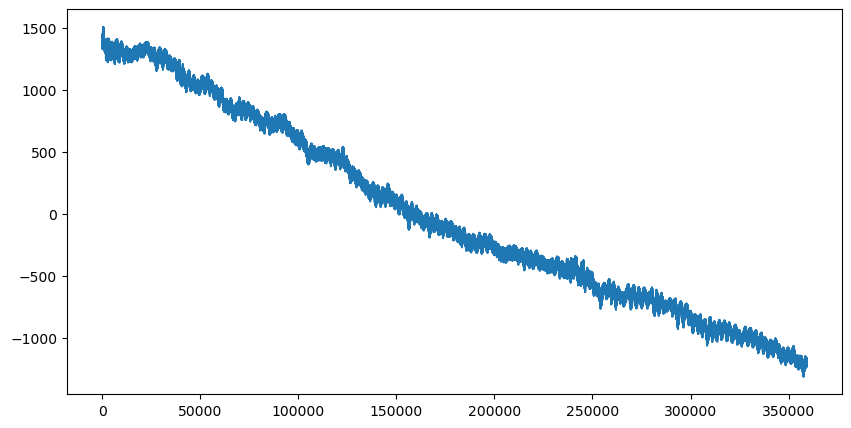

In [30]:
plt.figure(figsize=(10, 5))
i = 1
plt.plot(data[i, :], label=f"Channel {i+1}")

In [31]:
# filter data remove < 0.1 Hz
from scipy.signal import butter, filtfilt
def butter_bandpass(lowcut, highcut, fs, order=5):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype="band")
    return b, a
def butter_bandpass_filter(data, lowcut, highcut, fs, order=5):
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    y = filtfilt(b, a, data)
    return y
fs = 250
lowcut = 0.1
highcut = 50
filtered_data = butter_bandpass_filter(data[i, :], lowcut, highcut, fs, order=4)

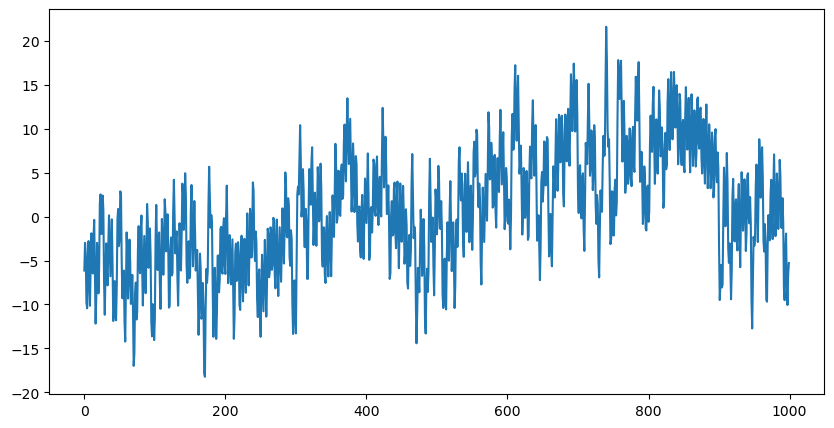

In [37]:
plt.figure(figsize=(10, 5))
plt.plot(filtered_data[20000:21000], label=f"Channel {i+1} (Filtered)")

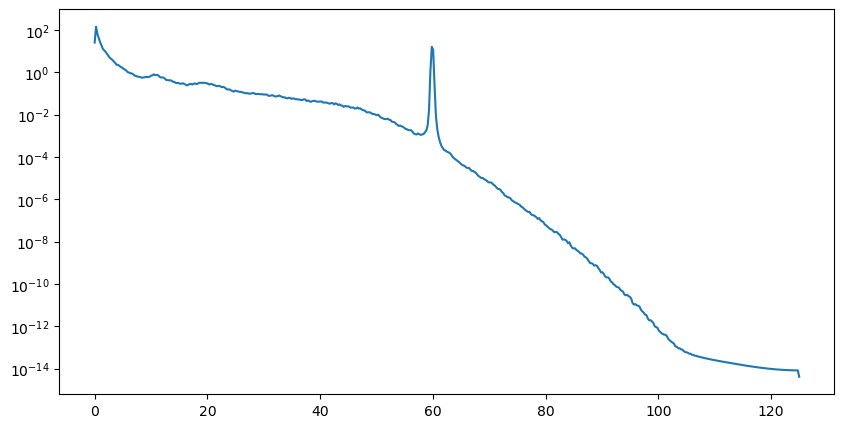

In [42]:
# psd
from scipy.signal import welch
f, Pxx = welch(filtered_data, fs, nperseg=1024)
plt.figure(figsize=(10, 5))
plt.semilogy(f, Pxx)

In [ ]:
# quick check to verify the path
import os
os.listdir("../data/music_eeg/sub-01/ses-01")

['aux_raw.npy',
 'eeg_raw.npy',
 'post_rec_epochs.npy',
 'pre_rec_epochs.npy',
 'segment_log.npy',
 'solve_events.npy',
 'timestamp_raw.npy']

In [ ]:
import mne

# Create the set file with info structure (channel names, event times)

convert_data_matlab


## aux_raw

will continue others later first just wanna try out eeg_raw